# 05 — Predictions & Feature Importance

**Goal:** Build predictive models to:
1. **Classify** passage outcome (Admis / Rattrapage) — binary classification
2. **Regress** annual average — continuous target
3. Identify which variables drive performance
4. Predict early (using only S1 data)

**Models covered:** Logistic Regression, Random Forest, Gradient Boosting,
with cross-validation and SHAP-style feature importance.



## 1. Imports



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     cross_val_predict, train_test_split,
                                     learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             mean_squared_error, mean_absolute_error, r2_score)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

CLEAN = Path("../data/clean")
FIG   = Path("../figures/predictions")
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)

panel = pd.read_csv(CLEAN / "panel_clustered.csv")
print(f"Panel loaded: {panel.shape}")
print(f"Passage distribution:\n{panel['passage'].value_counts()}")

# Identify available features
grade_cols = [c for c in panel.columns
              if c not in ["id","promo","moy_s1","moy_s2","moy_ann","rang",
                            "passage","passage_bin","rang_norm","delta_s2_s1",
                            "top_quartile","bottom_quartile","is_outlier",
                            "genre","origine","bac","licence","promotion",
                            "cluster_km","cluster_hac","cluster_label",
                            "silhouette","quartile_label"]
              and not c.startswith("mod_")]
mod_cols  = [c for c in panel.columns if c.startswith("mod_")]
demo_cols = [c for c in ["genre", "origine", "bac", "licence"] if c in panel.columns]


Panel loaded: (100, 55)
Passage distribution:
passage
Admis         84
Rattrapage    16
Name: count, dtype: int64


## 2. Feature Engineering



In [2]:
df = panel.copy()

# Encode categorical demographics
for col in demo_cols:
    le = LabelEncoder()
    df[f"{col}_enc"] = le.fit_transform(df[col].fillna("unknown"))
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

demo_enc = [f"{c}_enc" for c in demo_cols]
df["promo_enc"] = df["promo"].astype(int)

# Semester-only features (for early prediction)
s1_features  = ["moy_s1"] + [c for c in grade_cols + mod_cols
                               if "s1" in c.lower() or "S1" in c]
all_features = (["moy_s1", "moy_s2", "delta_s2_s1", "rang_norm"] +
                grade_cols + mod_cols + demo_enc + ["promo_enc"])
all_features = [c for c in all_features if c in df.columns]

print(f"\nAll features  : {all_features}")
print(f"S1-only feats : {s1_features}")


Encoded genre: {'f': np.int64(0), 'm': np.int64(1)}
Encoded origine: {'bizerte': np.int64(0), 'djebeniana': np.int64(1), 'gabes': np.int64(2), 'hammamet': np.int64(3), 'jendouba': np.int64(4), 'jerba': np.int64(5), 'kairouan': np.int64(6), 'kerkenah': np.int64(7), 'mahdia': np.int64(8), 'moknin': np.int64(9), 'monastir': np.int64(10), 'msaken': np.int64(11), 'médenine': np.int64(12), 'mégrine/ tunis': np.int64(13), 'nefta': np.int64(14), 'sfax': np.int64(15), 'sidi bouzid': np.int64(16), 'sousse': np.int64(17), 'tbarka': np.int64(18), 'tunis': np.int64(19), 'unknown': np.int64(20)}
Encoded bac: {'informatique': np.int64(0), 'math': np.int64(1), 'science': np.int64(2), 'technique': np.int64(3), 'unknown': np.int64(4)}
Encoded licence: {'licence': np.int64(0), 'pisi': np.int64(1)}

All features  : ['moy_s1', 'moy_s2', 'delta_s2_s1', 'rang_norm', 'Devp mob', 'TOEIC3', 'TOEIC4', 'agile', 'algo num2', 'algo.num1', 'appr auto', "ches de mkv-fil d'at", 'cloud comp', 'devops1', 'dt des entpses

## 3. Task 1 — Classify Passage Outcome



In [3]:
# Target
y_cls = df["passage_bin"]

# Feature matrix — full (uses S1+S2)
X_full = df[all_features].fillna(df[all_features].median())

# Feature matrix — S1 only (early warning system)
s1_feat_avail = [c for c in s1_features if c in df.columns]
X_s1 = df[s1_feat_avail].fillna(df[s1_feat_avail].median()) if s1_feat_avail else X_full

print(f"Classification target: {y_cls.value_counts().to_dict()}")
print(f"Class balance: {y_cls.mean()*100:.1f}% Admis")
print(f"Full feature set: {X_full.shape[1]} features")
print(f"S1-only feature set: {X_s1.shape[1]} features")


Classification target: {1: 84, 0: 16}
Class balance: 84.0% Admis
Full feature set: 43 features
S1-only feature set: 2 features


### 3a. Cross-Validated Model Comparison



In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

classifiers = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                        random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                            max_depth=3, random_state=42))
    ]),
}

results = {}
for name, clf in classifiers.items():
    auc_scores = cross_val_score(clf, X_full, y_cls, cv=cv, scoring="roc_auc")
    acc_scores = cross_val_score(clf, X_full, y_cls, cv=cv, scoring="accuracy")
    results[name] = {
        "AUC mean": auc_scores.mean(),
        "AUC std" : auc_scores.std(),
        "Acc mean": acc_scores.mean(),
        "Acc std" : acc_scores.std(),
    }
    print(f"{name:25s}: AUC={auc_scores.mean():.3f} (+/-{auc_scores.std():.3f})"
          f"  Acc={acc_scores.mean():.3f} (+/-{acc_scores.std():.3f})")

results_df = pd.DataFrame(results).T.round(3)
print(f"\n{results_df}")


Logistic Regression      : AUC=0.887 (+/-0.070)  Acc=0.840 (+/-0.066)
Random Forest            : AUC=0.942 (+/-0.057)  Acc=0.930 (+/-0.040)
Gradient Boosting        : AUC=0.961 (+/-0.065)  Acc=0.970 (+/-0.024)

                     AUC mean  AUC std  Acc mean  Acc std
Logistic Regression     0.887    0.070     0.840    0.066
Random Forest           0.942    0.057     0.930    0.040
Gradient Boosting       0.961    0.065     0.970    0.024


### 3b. Best Model — Detailed Evaluation




Best model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

  Rattrapage       0.93      0.88      0.90        16
       Admis       0.98      0.99      0.98        84

    accuracy                           0.97       100
   macro avg       0.95      0.93      0.94       100
weighted avg       0.97      0.97      0.97       100



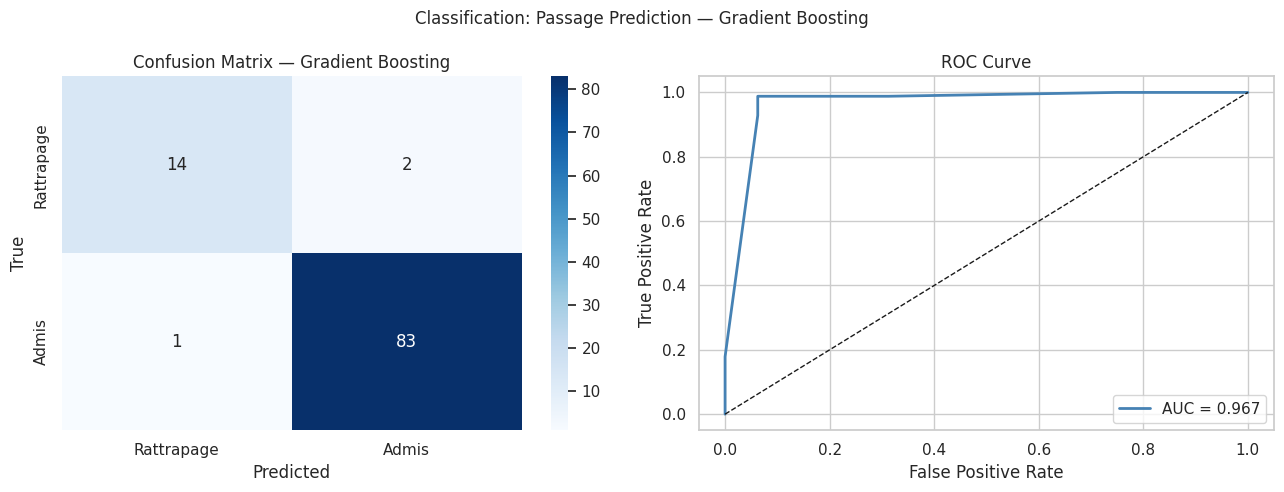

In [5]:
# Pick best by AUC
best_name = results_df["AUC mean"].idxmax()
best_clf  = classifiers[best_name]
print(f"\nBest model: {best_name}")

# Fit and evaluate with CV predictions
y_pred  = cross_val_predict(best_clf, X_full, y_cls, cv=cv)
y_proba = cross_val_predict(best_clf, X_full, y_cls, cv=cv, method="predict_proba")[:, 1]

print("\nClassification Report:")
print(classification_report(y_cls, y_pred, target_names=["Rattrapage", "Admis"]))

# Confusion matrix
cm = confusion_matrix(y_cls, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Rattrapage", "Admis"],
            yticklabels=["Rattrapage", "Admis"])
ax.set_title(f"Confusion Matrix — {best_name}")
ax.set_ylabel("True")
ax.set_xlabel("Predicted")

# ROC curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_cls, y_proba)
auc = roc_auc_score(y_cls, y_proba)
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.3f}")
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()

plt.suptitle(f"Classification: Passage Prediction — {best_name}", fontsize=12)
plt.tight_layout()
plt.savefig(FIG / "classification_results.png", dpi=150)
plt.show()


### 3c. Early Warning — S1-Only Model



In [6]:
print("=== Early Warning: S1-Only Features ===")
print(f"Features used: {s1_feat_avail}")

if len(s1_feat_avail) >= 1:
    s1_results = {}
    for name, clf in classifiers.items():
        auc = cross_val_score(clf, X_s1, y_cls, cv=cv, scoring="roc_auc").mean()
        acc = cross_val_score(clf, X_s1, y_cls, cv=cv, scoring="accuracy").mean()
        s1_results[name] = {"AUC": auc, "Acc": acc}
        print(f"{name:25s}: AUC={auc:.3f}  Acc={acc:.3f}")

    print("\nFull vs S1-only AUC comparison:")
    for name in classifiers:
        full_auc = results[name]["AUC mean"]
        s1_auc   = s1_results[name]["AUC"]
        print(f"  {name}: full={full_auc:.3f}  s1-only={s1_auc:.3f}  "
              f"loss={full_auc - s1_auc:.3f}")


=== Early Warning: S1-Only Features ===
Features used: ['moy_s1', 'devops1']
Logistic Regression      : AUC=0.914  Acc=0.870
Random Forest            : AUC=0.886  Acc=0.890
Gradient Boosting        : AUC=0.895  Acc=0.850

Full vs S1-only AUC comparison:
  Logistic Regression: full=0.887  s1-only=0.914  loss=-0.027
  Random Forest: full=0.942  s1-only=0.886  loss=0.056
  Gradient Boosting: full=0.961  s1-only=0.895  loss=0.066


## 4. Task 2 — Regress Annual Average



In [7]:
# Remove moy_ann from features (target leakage prevention)
reg_features = [c for c in all_features
                if c not in ["moy_ann", "rang", "rang_norm", "passage_bin",
                              "top_quartile", "bottom_quartile"]]
# Also keep moy_s1, moy_s2 (they're legitimate predictors of the combined annual avg
# if it's a weighted average; in practice use only S1 to predict the outcome)
# For a more realistic early prediction, restrict to s1 features only:
reg_features_early = [c for c in s1_feat_avail + demo_enc + ["promo_enc"]
                      if c in df.columns and c != "moy_ann"]

y_reg = df["moy_ann"]
X_reg = df[reg_features].fillna(df[reg_features].median())
X_reg_early = df[reg_features_early].fillna(df[reg_features_early].median())

print(f"Regression target: moy_ann  (mean={y_reg.mean():.2f}, std={y_reg.std():.2f})")

regressors = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=1.0))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", GradientBoostingRegressor(n_estimators=150, learning_rate=0.1,
                                           max_depth=3, random_state=42))
    ]),
}

cv_reg = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nRegressor performance (5-fold CV):")
for name, reg in regressors.items():
    r2   = cross_val_score(reg, X_reg, y_reg, cv=5, scoring="r2").mean()
    rmse = np.sqrt(-cross_val_score(reg, X_reg, y_reg, cv=5,
                                     scoring="neg_mean_squared_error").mean())
    print(f"  {name:20s}: R2={r2:.3f}  RMSE={rmse:.3f}")


Regression target: moy_ann  (mean=12.58, std=1.57)

Regressor performance (5-fold CV):
  Ridge               : R2=1.000  RMSE=0.005
  Random Forest       : R2=0.920  RMSE=0.475
  Gradient Boosting   : R2=0.936  RMSE=0.423


### 4a. Predicted vs Actual Plot (best regressor)



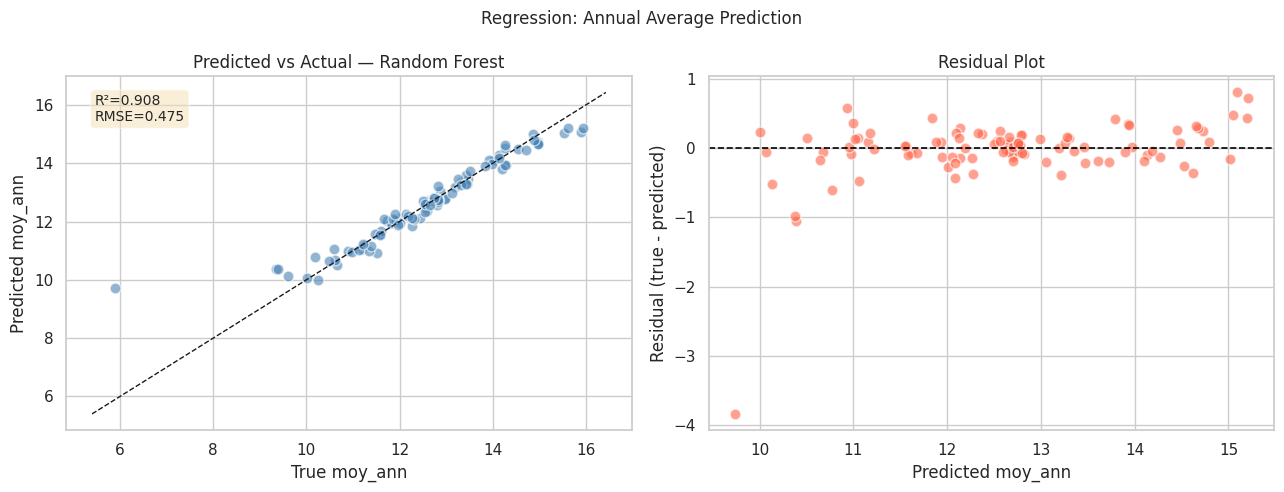

In [8]:
best_reg_name = "Random Forest"
best_reg = regressors[best_reg_name]
y_pred_reg = cross_val_predict(best_reg, X_reg, y_reg, cv=5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_reg, y_pred_reg, alpha=0.6, color="steelblue", edgecolors="white", s=60)
lims = [min(y_reg.min(), y_pred_reg.min()) - 0.5,
        max(y_reg.max(), y_pred_reg.max()) + 0.5]
ax.plot(lims, lims, "k--", lw=1)
ax.set_xlabel("True moy_ann")
ax.set_ylabel("Predicted moy_ann")
ax.set_title(f"Predicted vs Actual — {best_reg_name}")
r2 = r2_score(y_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg, y_pred_reg))
ax.text(0.05, 0.95, f"R²={r2:.3f}\nRMSE={rmse:.3f}",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# Residuals
ax = axes[1]
residuals = y_reg - y_pred_reg
ax.scatter(y_pred_reg, residuals, alpha=0.6, color="tomato", edgecolors="white", s=60)
ax.axhline(0, color="black", lw=1.2, linestyle="--")
ax.set_xlabel("Predicted moy_ann")
ax.set_ylabel("Residual (true - predicted)")
ax.set_title("Residual Plot")

plt.suptitle("Regression: Annual Average Prediction", fontsize=12)
plt.tight_layout()
plt.savefig(FIG / "regression_results.png", dpi=150)
plt.show()


## 5. Feature Importance



In [9]:
# Fit full RF classifier and regressor for importance
best_clf.fit(X_full, y_cls)
best_reg.fit(X_reg, y_reg)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_sa

### 5a. Permutation Importance — Classifier



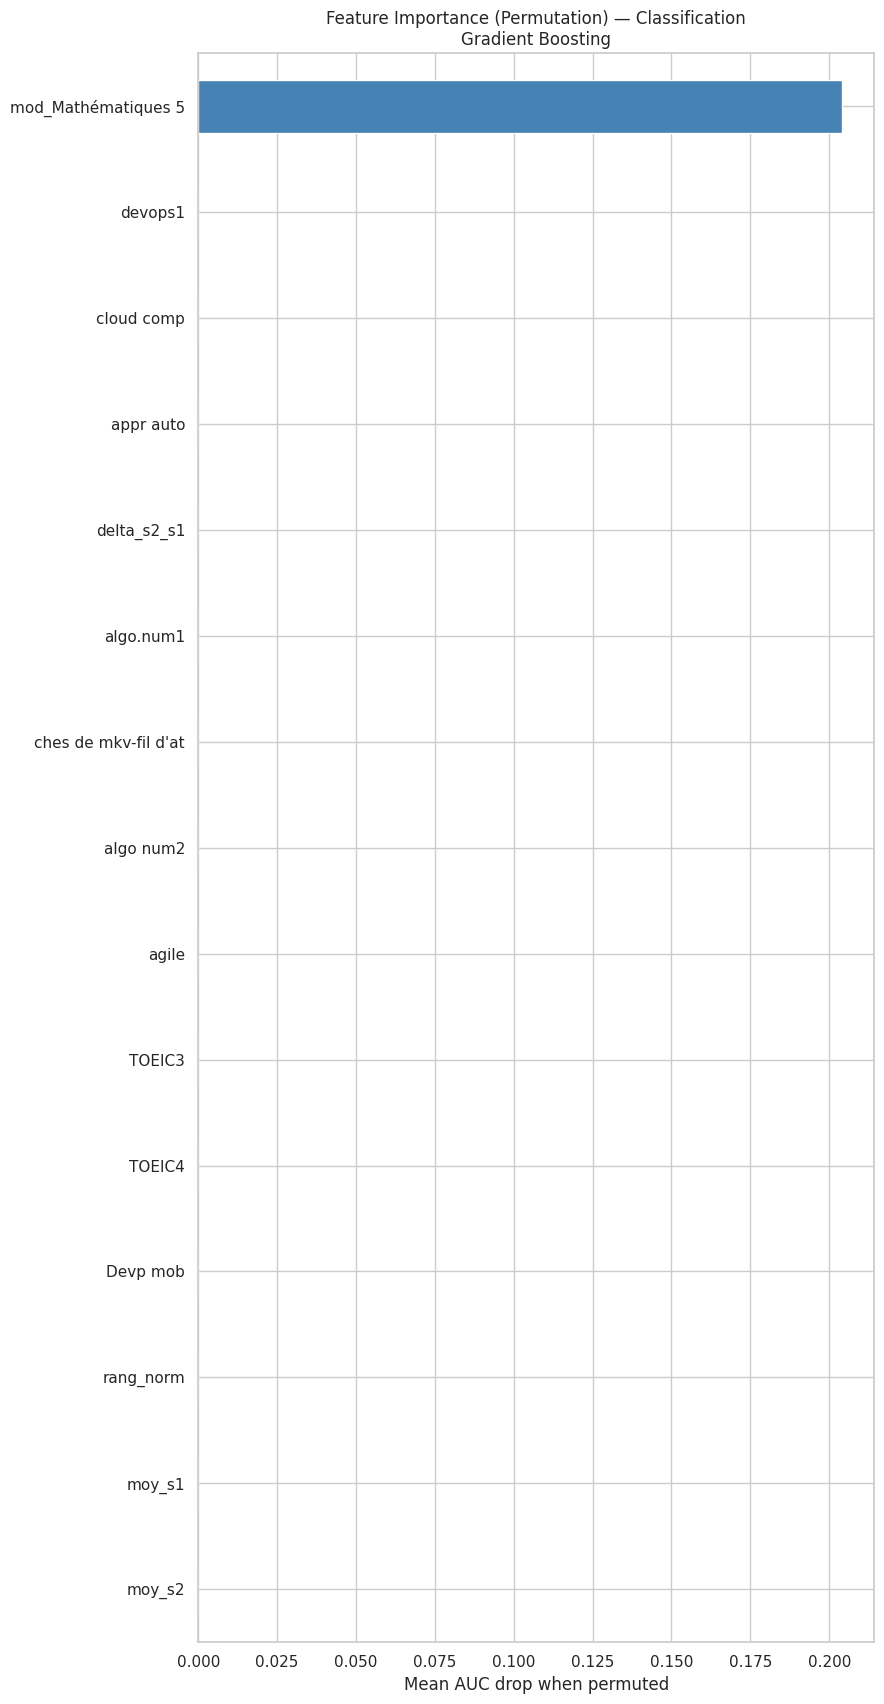


Top features for passage prediction:
mod_Mathématiques 5   0.204
moy_s2                0.000
moy_s1                0.000
rang_norm             0.000
Devp mob              0.000
TOEIC3                0.000
TOEIC4                0.000
agile                 0.000
algo num2             0.000
algo.num1             0.000
dtype: float64


In [10]:
X_tr_cls, X_te_cls, y_tr_cls, y_te_cls = train_test_split(
    X_full, y_cls, test_size=0.3, random_state=42, stratify=y_cls)

best_clf.fit(X_tr_cls, y_tr_cls)
perm_cls = permutation_importance(best_clf, X_te_cls, y_te_cls,
                                    n_repeats=20, random_state=42, scoring="roc_auc")
imp_cls = pd.Series(perm_cls.importances_mean, index=all_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(4, len(imp_cls) * 0.4)))
top_n = min(15, len(imp_cls))
imp_cls.head(top_n).sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title(f"Feature Importance (Permutation) — Classification\n{best_name}")
ax.set_xlabel("Mean AUC drop when permuted")
plt.tight_layout()
plt.savefig(FIG / "feat_importance_classification.png", dpi=150)
plt.show()

print("\nTop features for passage prediction:")
print(imp_cls.head(10).round(4))


### 5b. Permutation Importance — Regressor



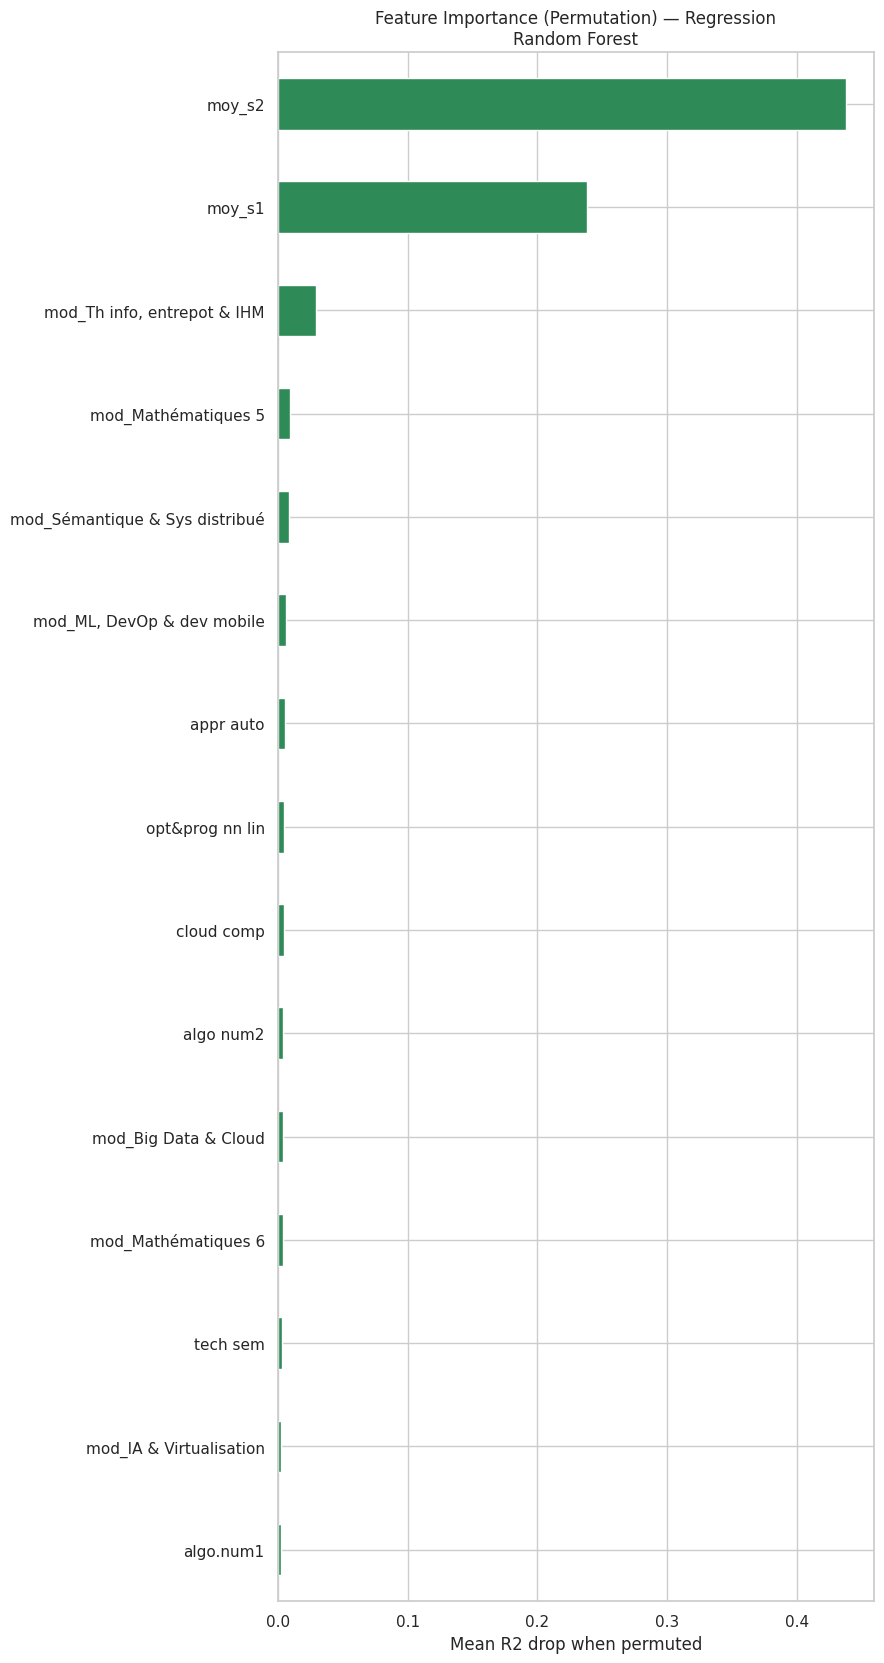


Top features for average grade prediction:
moy_s2                           0.438
moy_s1                           0.238
mod_Th info, entrepot & IHM      0.029
mod_Mathématiques 5              0.009
mod_Sémantique & Sys distribué   0.009
mod_ML, DevOp & dev mobile       0.006
appr auto                        0.005
opt&prog nn lin                  0.005
cloud comp                       0.004
algo num2                        0.004
dtype: float64


In [11]:
X_tr_reg, X_te_reg, y_tr_reg, y_te_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42)

best_reg.fit(X_tr_reg, y_tr_reg)
perm_reg = permutation_importance(best_reg, X_te_reg, y_te_reg,
                                    n_repeats=20, random_state=42, scoring="r2")
imp_reg = pd.Series(perm_reg.importances_mean, index=reg_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, max(4, len(imp_reg) * 0.4)))
imp_reg.head(top_n).sort_values().plot.barh(ax=ax, color="seagreen")
ax.set_title(f"Feature Importance (Permutation) — Regression\n{best_reg_name}")
ax.set_xlabel("Mean R2 drop when permuted")
plt.tight_layout()
plt.savefig(FIG / "feat_importance_regression.png", dpi=150)
plt.show()

print("\nTop features for average grade prediction:")
print(imp_reg.head(10).round(4))


## 6. Learning Curves

Diagnose bias/variance tradeoff: does adding more data help?



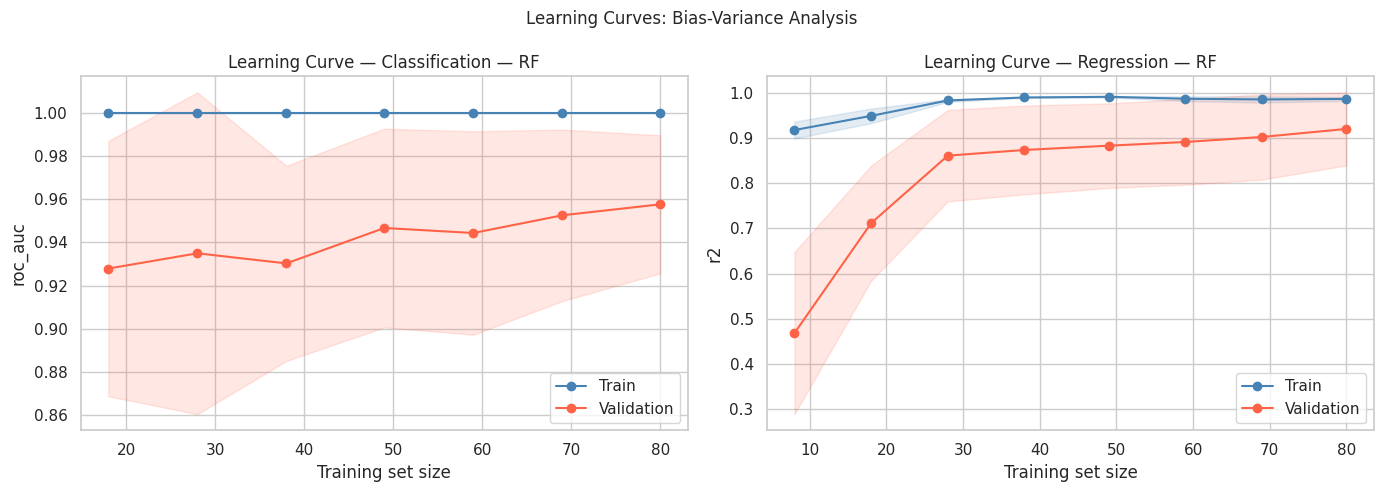

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model, X_data, y_data, scoring) in zip(axes, [
    ("Classification — RF", classifiers["Random Forest"], X_full, y_cls, "roc_auc"),
    ("Regression — RF",     regressors["Random Forest"],  X_reg,  y_reg, "r2"),
]):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_data, y_data, cv=5, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
    )
    tr_mean = train_scores.mean(axis=1)
    tr_std  = train_scores.std(axis=1)
    va_mean = val_scores.mean(axis=1)
    va_std  = val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, "o-", color="steelblue", label="Train")
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color="steelblue")
    ax.plot(train_sizes, va_mean, "o-", color="tomato", label="Validation")
    ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, alpha=0.15, color="tomato")
    ax.set_xlabel("Training set size")
    ax.set_ylabel(scoring)
    ax.set_title(f"Learning Curve — {name}")
    ax.legend()

plt.suptitle("Learning Curves: Bias-Variance Analysis", fontsize=12)
plt.tight_layout()
plt.savefig(FIG / "learning_curves.png", dpi=150)
plt.show()


## 7. Promo-Level Predictions

Train on promos 1+2, predict on promo 3 (temporal validation).



In [13]:
print("=== Temporal Cross-Promo Validation ===")
print("Train on Promo 1+2, Predict on Promo 3\n")

train_mask = df["promo"].isin([1, 2])
test_mask  = df["promo"] == 3

X_tr = X_full[train_mask]; y_tr = y_cls[train_mask]
X_te = X_full[test_mask];  y_te = y_cls[test_mask]

for name, clf in classifiers.items():
    clf.fit(X_tr, y_tr)
    y_p = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te)[:, 1]
    acc = (y_p == y_te).mean()
    try:
        auc = roc_auc_score(y_te, y_prob)
    except Exception:
        auc = float("nan")
    print(f"  {name:25s}: Acc={acc:.3f}  AUC={auc:.3f}")

print("\nNote: Low n in test set (Promo 3 only) — interpret with caution.")


=== Temporal Cross-Promo Validation ===
Train on Promo 1+2, Predict on Promo 3

  Logistic Regression      : Acc=0.875  AUC=0.917
  Random Forest            : Acc=0.969  AUC=0.967
  Gradient Boosting        : Acc=0.969  AUC=1.000

Note: Low n in test set (Promo 3 only) — interpret with caution.


## 8. Summary Table



In [14]:
print("\n" + "="*60)
print("PREDICTION SUMMARY")
print("="*60)
print(f"\nTask 1 — Passage Classification (5-fold CV):")
print(results_df[["AUC mean", "AUC std", "Acc mean"]].to_string())

print(f"\nTask 2 — Annual Average Regression (5-fold CV):")
for name, reg in regressors.items():
    r2 = cross_val_score(reg, X_reg, y_reg, cv=5, scoring="r2").mean()
    print(f"  {name:20s}: R2={r2:.3f}")

print(f"\nTop 5 features for passage prediction:")
print(imp_cls.head(5).round(4).to_string())

print(f"\nTop 5 features for grade prediction:")
print(imp_reg.head(5).round(4).to_string())

print("\nKey insight: If moy_s1 is the top predictor of passage,")
print("an early-warning system based on S1 performance is viable.")



PREDICTION SUMMARY

Task 1 — Passage Classification (5-fold CV):
                     AUC mean  AUC std  Acc mean
Logistic Regression     0.887    0.070     0.840
Random Forest           0.942    0.057     0.930
Gradient Boosting       0.961    0.065     0.970

Task 2 — Annual Average Regression (5-fold CV):
  Ridge               : R2=1.000
  Random Forest       : R2=0.920
  Gradient Boosting   : R2=0.936

Top 5 features for passage prediction:
mod_Mathématiques 5   0.204
moy_s2                0.000
moy_s1                0.000
rang_norm             0.000
Devp mob              0.000

Top 5 features for grade prediction:
moy_s2                           0.438
moy_s1                           0.238
mod_Th info, entrepot & IHM      0.029
mod_Mathématiques 5              0.009
mod_Sémantique & Sys distribué   0.009

Key insight: If moy_s1 is the top predictor of passage,
an early-warning system based on S1 performance is viable.
